<a href="https://colab.research.google.com/github/AHamamd150/KEK_Lectures/blob/main/notebooks/Lecture2_DNN_MNIST_digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Multi-Layer Perceptron (MLP) — MNIST Digit Classification


---

## 📌 What is this notebook about?

In this notebook, we build a **Neural Network** that can look at a handwritten digit image and tell us which number it is (0–9).  
We use the famous **MNIST** dataset — 70,000 small images of handwritten digits.

---

## 🧠 Network structure

Here is the structure of our MLP:

```
INPUT LAYER        HIDDEN LAYERS          OUTPUT LAYER
(image pixels) →   (learn patterns)   →  (digit 0–9)
  784 neurons     512 → 256 → 128          10 neurons
```

- **Input layer**: receives raw pixel values of the image
- **Hidden layers**: learn features like edges, curves, shapes
- **Output layer**: gives a probability for each digit (0–9)
---

## 📦 Section 1 — Import Libraries

Before writing any code, we load the **tools (libraries)** we will use.  
Think of this like gathering lab equipment before starting an experiment.

In [1]:
import numpy as np           # NumPy: handles large arrays of numbers efficiently; 'np' is the standard alias
import matplotlib.pyplot as plt  # Matplotlib: the main plotting library; 'plt' is the standard alias

import tensorflow as tf      # TensorFlow: the main deep learning framework (developed by Google)
from tensorflow import keras # Keras: a simpler, beginner-friendly interface built on top of TensorFlow
from keras.datasets import mnist  # Import the MNIST dataset module (built into Keras — no download needed)

print('All libraries imported successfully!')     # Confirm everything loaded without errors
print(f'TensorFlow version: {tf.__version__}')  # Display TensorFlow version for reference

All libraries imported successfully!
TensorFlow version: 2.19.0


---
## 🗂️ Section 2 — Load the MNIST Dataset

The **MNIST dataset** contains **70,000 grayscale images** of handwritten digits (0–9), each **28 × 28 pixels**.

| Split | Images | Purpose |
|-------|--------|---------|
| Training set | 60,000 | Used to *teach* the model |
| Test set | 10,000 | Used to *evaluate* on unseen data |

> 💡 **Analogy**: Training set = practice exam questions. Test set = the real exam.

Keras has this dataset built-in, so no manual download is needed.

In [2]:
# Load and immediately split the dataset into training and test portions
# x_train → 60,000 images the model WILL learn from
# y_train → 60,000 correct digit labels for those training images
# x_test  → 10,000 images the model will NEVER see during training
# y_test  → 10,000 correct digit labels for the test images
(x_train, y_train), (x_test, y_test) = mnist.load_data()  # Returns two (images, labels) tuples

print('Data loaded successfully!')  # Confirm the data loaded without errors

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded successfully!


---
## 🔍 Section 3 — Explore and Understand the Data

Before training any model, we always **explore the data** first.  
This helps us understand what we are working with and spot any issues early.

In [3]:
# Print the shape (dimensions) of the image arrays
# Shape format: (number_of_images, image_height, image_width)
print('Training images shape:', x_train.shape)  # Expect: (60000, 28, 28)
print('Test images shape:    ', x_test.shape)   # Expect: (10000, 28, 28)

# Print the shape of the label arrays
# Labels are simply integers: 0, 1, 2, ..., 9
print('Training labels shape:', y_train.shape)  # Expect: (60000,)
print('Test labels shape:    ', y_test.shape)   # Expect: (10000,)

# Print the pixel value range BEFORE normalization
# Raw grayscale images range from 0 (black pixel) to 255 (white pixel)
print(f'\nPixel value range — Min: {x_train.min()}, Max: {x_train.max()}')

# Show the first 10 labels as a quick sanity check
print(f'First 10 labels: {y_train[:10]}')

Training images shape: (60000, 28, 28)
Test images shape:     (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape:     (10000,)

Pixel value range — Min: 0, Max: 255
First 10 labels: [5 0 4 1 9 2 1 3 1 4]


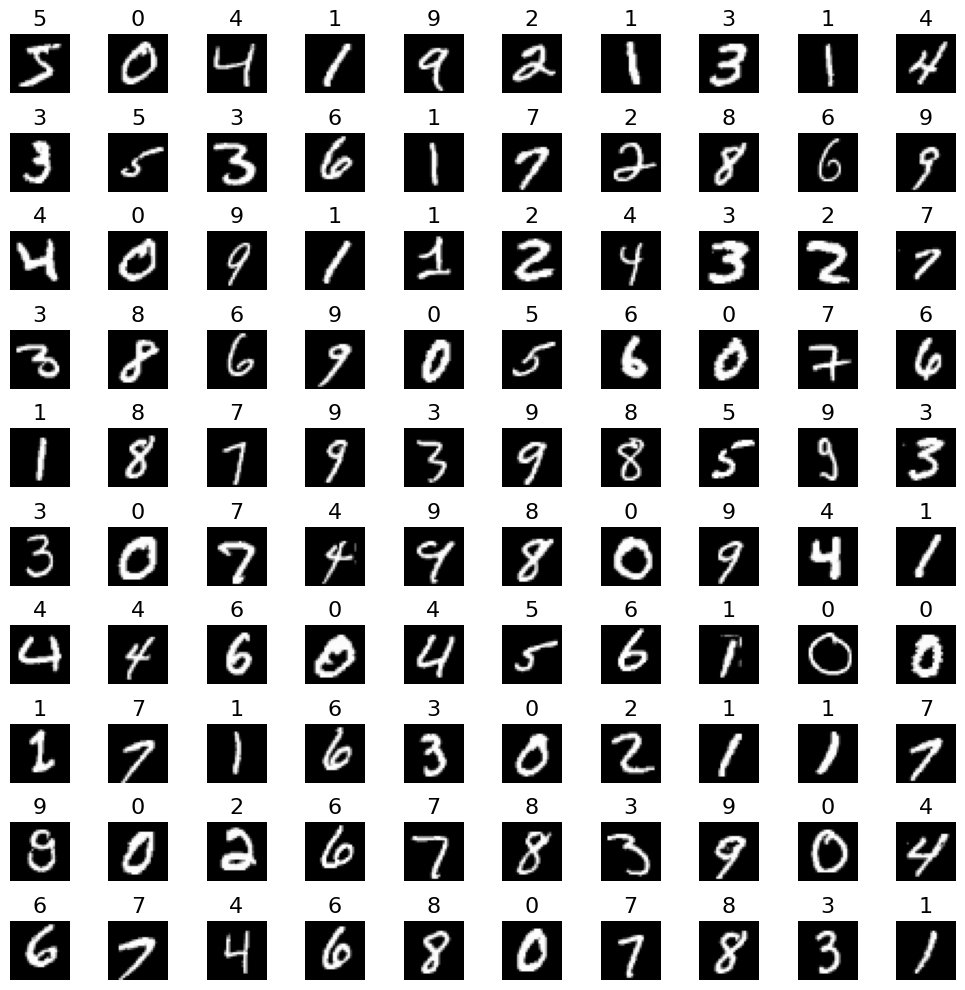

In [6]:
# Visualize a grid of 100 training images to see the variety in the dataset
fig = plt.figure(figsize=(10, 10))  # Larger figure = larger individual images (was 10×5)

for q in range(100):  # Loop through the first 100 training images
    fig.add_subplot(10, 10, q + 1)  # Add subplot in a 10-row × 10-column grid (index must start at 1)
    plt.imshow(x_train[q], cmap='gray')   # Display image number q in grayscale
    plt.title(str(y_train[q]), fontsize=16) # Increased font size to match the larger images (was 7)
    plt.axis('off')  # Remove axis ticks and numbers for a cleaner look

plt.tight_layout()  # Adjust spacing so sub-plots do not overlap each other


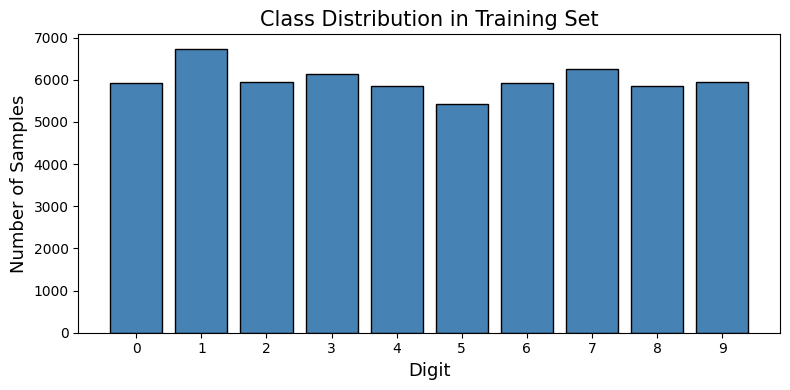

In [7]:
# Count how many training examples exist for each digit class (0–9)
# A balanced dataset means the model won't be biased toward any particular digit
unique, counts = np.unique(y_train, return_counts=True)  # np.unique finds unique values and their frequencies

plt.figure(figsize=(8, 4))                                       # Create figure
plt.bar(unique, counts, color='steelblue', edgecolor='black')    # Bar chart: x=digit (0–9), y=count
plt.xlabel('Digit', fontsize=13)                                 # Label the x-axis
plt.ylabel('Number of Samples', fontsize=13)                     # Label the y-axis
plt.title('Class Distribution in Training Set', fontsize=15)     # Chart title
plt.xticks(range(10))  # Force tick marks at each integer 0 through 9
plt.tight_layout()     # Prevent clipping
plt.show()             # Display the chart

---
## ⚙️ Section 4 — Preprocess the Data

Raw data is almost never in the right format for a neural network. We need to prepare it:

### 4a. Normalize pixel values
Pixels currently range **0–255**. We divide by 255 to squeeze all values into **[0, 1]**.  
> 💡 Large inputs cause large, unstable weight updates. Small, consistent inputs make training much better-behaved.

### 4b. Labels — keep them as integers (no one-hot encoding needed!)
The labels stay as plain integers: `0, 1, 2, ..., 9`.  
We will use **`sparse_categorical_crossentropy`** as the loss function, which accepts integer labels directly — no conversion required.

| Approach | Label format | Loss function |
|----------|-------------|---------------|
| One-hot encoding | `[0,0,0,0,0,1,0,0,0,0]` | `categorical_crossentropy` |
| **Sparse (this notebook)** | **`5`** | **`sparse_categorical_crossentropy`** |

> 💡 Both approaches give **identical results**. Sparse is simpler and uses less memory because we skip creating the big one-hot matrix.


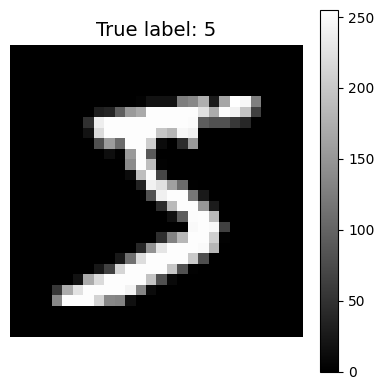

In [8]:
# Visualize a single image to understand what one data sample looks like
plt.figure(figsize=(4, 4))                        # Create a 4×4 inch figure
plt.imshow(x_train[0], cmap='gray')               # Display the first training image in grayscale
plt.title(f'True label: {y_train[0]}', fontsize=14)  # Show the correct digit as the title
plt.colorbar()  # Color scale: values near 0 = dark/black, near 255 = bright/white
plt.axis('off') # Hide the pixel-index numbers on the axes — they are not informative here
plt.tight_layout()  # Prevent layout elements from being clipped
plt.show()  # Render and display the plot

In [9]:
# ── 4a. Normalize pixel values ────────────────────────────────────────────────

# reshape(-1, 28, 28, 1):
#   -1 means 'keep the number of images as-is'
#   28, 28 = image height and width in pixels
#   1 = number of color channels (grayscale = 1 channel; color RGB would be 3)
# /255.0: divide every pixel value by 255 so the range becomes [0.0, 1.0]
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0  # Normalize training images
x_test  = x_test.reshape(-1, 28, 28, 1)  / 255.0  # Normalize test images (same operation)

# Verify the new value range
print(f'After normalization — Min: {x_train.min():.1f}, Max: {x_train.max():.1f}')  # Should print 0.0 and 1.0
print(f'New training data shape: {x_train.shape}')  # Expect: (60000, 28, 28, 1)

After normalization — Min: 0.0, Max: 1.0
New training data shape: (60000, 28, 28, 1)


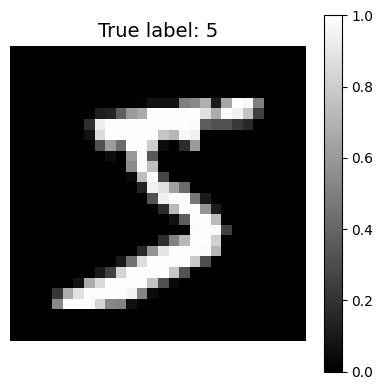

In [10]:
# Visualize a single image to understand what one data sample looks like
plt.figure(figsize=(4, 4))                        # Create a 4×4 inch figure
plt.imshow(x_train[0], cmap='gray')               # Display the first training image in grayscale
plt.title(f'True label: {y_train[0]}', fontsize=14)  # Show the correct digit as the title
plt.colorbar()  # Color scale: values near 0 = dark/black, near 255 = bright/white
plt.axis('off') # Hide the pixel-index numbers on the axes — they are not informative here
plt.tight_layout()  # Prevent layout elements from being clipped
plt.show()  # Render and display the plot

In [11]:
# ── 4b. Label preview — no one-hot encoding needed ───────────────────────────

# With sparse_categorical_crossentropy the labels stay as plain integers (0–9)
# There is nothing to convert — we just verify the labels look correct
print('Label preview (first 10 training labels):\n')

# Print a simple table header
print(f"{'Index':>6}  {'Label':>6}")  # Right-aligned column headers
print('-' * 16)                        # Separator line

for i in range(10):                              # Loop over the first 10 examples
    print(f"{i:>6}  {int(y_train[i]):>6}")  # Print index and its integer label

Label preview (first 10 training labels):

 Index   Label
----------------
     0       5
     1       0
     2       4
     3       1
     4       9
     5       2
     6       1
     7       3
     8       1
     9       4


---
## 🏗️ Section 5 — Build the Neural Network Architecture

Now we design the network. Think of this like designing an experiment pipeline.

```
Input image (28×28×1)
       ↓
  Flatten  →  784 numbers
       ↓
 Dense(512) + ReLU       ← Hidden Layer 1
       ↓
 BatchNorm + Dropout(0.3)
       ↓
 Dense(256) + ReLU       ← Hidden Layer 2
       ↓
 BatchNorm + Dropout(0.3)
       ↓
 Dense(128) + ReLU       ← Hidden Layer 3
       ↓
 Dropout(0.2)
       ↓
 Dense(10) + Softmax     ← Output (one neuron per digit)
```

**Key concepts:**
- **ReLU**: Outputs `max(0, x)` — introduces non-linearity so the network learns complex patterns
- **Dropout**: Randomly disables neurons during training — prevents overfitting (memorising instead of learning)
- **BatchNormalization**: Normalizes each layer's outputs — stabilizes and speeds up training
- **Softmax**: Converts raw scores into probabilities that all sum to 1 — perfect for classification

In [12]:
# Build the model using the Keras Sequential API
# Sequential = layers stacked one after another in a simple pipeline
model = keras.Sequential([

    # ── Flatten layer ────────────────────────────────────────────────────────
    # Converts the 2D image (28×28 pixels) into a 1D array of 784 values
    # Neural networks need a flat input vector, not a 2D grid
    keras.layers.Flatten(input_shape=(28, 28, 1)),  # input_shape must match our preprocessed data shape

    # ── Hidden Layer 1 ───────────────────────────────────────────────────────
    # Dense = fully connected: every neuron connects to all 784 inputs
    # 512 neurons to extract a rich set of low-level features
    # activation='relu' applies ReLU: f(x) = max(0, x) — introduces non-linearity
    keras.layers.Dense(512, activation='relu'),

    # BatchNormalization: normalises each mini-batch's output to mean≈0, variance≈1
    # This keeps activations in a healthy range and speeds up convergence
    keras.layers.BatchNormalization(),

    # Dropout(0.3): randomly sets 30% of neurons to 0 during each training step
    # Forces the network to learn robust features that don't rely on any single neuron
    keras.layers.Dropout(0.3),

    # ── Hidden Layer 2 ───────────────────────────────────────────────────────
    # 256 neurons — we reduce size as we go deeper (compression/funnel pattern)
    # Each successive layer learns increasingly abstract representations
    keras.layers.Dense(256, activation='relu'),

    keras.layers.BatchNormalization(),  # Stabilise outputs before the next layer
    keras.layers.Dropout(0.3),          # Regularise again to prevent overfitting

    # ── Hidden Layer 3 ───────────────────────────────────────────────────────
    # 128 neurons — further compresses the representation
    keras.layers.Dense(128, activation='relu'),


    # ── Output Layer ─────────────────────────────────────────────────────────
    # 10 neurons — one for each digit class (0 through 9)
    # activation='softmax' converts raw scores into probabilities that sum to 1.0
    # e.g., [0.01, 0.02, 0.01, 0.90, ...] means 90% probability it is digit 3
    keras.layers.Dense(10, activation='softmax')

])

# Print a summary: lists every layer, its output shape, and its trainable parameter count
# 'Parameters' = the numbers (weights & biases) the model adjusts during training
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

---
## ⚙️ Section 6 — Compile the Model

Before training, we **compile** the model — configure how it learns.

| Setting | Our Choice | Meaning |
|---------|------------|---------|
| **Optimizer** | Adam (lr=0.001) | Automatically adapts the learning speed |
| **Loss function** | Sparse Categorical Crossentropy | Same as categorical crossentropy but works directly with **integer** labels — no one-hot encoding needed |
| **Metric** | Accuracy | % of images correctly classified — easy to interpret |


In [13]:
model.compile(
    # Adam optimizer: adapts the learning rate automatically during training
    # learning_rate=0.001 is the standard starting point (smaller = more careful updates)
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # Loss function: 'sparse_categorical_crossentropy' works exactly like
    # categorical_crossentropy but accepts raw integer labels (0–9) directly
    # instead of one-hot vectors — simpler and more memory-efficient
    loss='sparse_categorical_crossentropy',

    # Metrics: what we track and display during training
    # 'accuracy' = (correct predictions) / (total predictions)
    metrics=['accuracy']
)

print('Model compiled and ready to train!')

Model compiled and ready to train!


---
## 🏋️ Section 7 — Train the Model

Training is when the model **actually learns** from the data.

Key parameters:
- **epochs**: How many times the model sees the full training dataset
- **batch_size**: How many images to process before updating weights
- **validation_split**: Hold out 20% of training data to monitor generalisation *during* training

We also use **callbacks** — automatic actions triggered during training:
- **EarlyStopping**: halts training if no improvement is seen for 5 epochs (saves time, avoids overfitting)
- **ReduceLROnPlateau**: lowers the learning rate when stuck — like fine-tuning at the end of an experiment

> 💡 **Overfitting** = the model memorises training data but fails on new data — like a student who only memorises past exam answers.

In [14]:
# EarlyStopping: stops training automatically if val_loss doesn't improve
# monitor='val_loss'        → watch the validation loss (not training loss)
# patience=5                → wait 5 consecutive epochs with no improvement before stopping
# restore_best_weights=True → revert to the best weights seen, not the last ones
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# model.fit() is the main training function
# It iterates over batches of data, computes the loss, and updates the model weights
# Returns a 'history' object that stores accuracy and loss at each epoch
history = model.fit(
    x_train,   # Training images (inputs)
    y_train,   # Training labels — plain integers 0–9 (sparse_categorical_crossentropy handles these directly)
    epochs=30,           # Maximum epochs; EarlyStopping may halt before this
    batch_size=512,      # Process 512 images at a time before updating weights
    validation_split=0.2, # Use 20% of training data (12,000 images) as a validation set
    callbacks=[early_stop],  # Apply our callback
    verbose=1            # 1 = print a progress bar per epoch; 0 = silent
)

print('\nTraining complete!')

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.8769 - loss: 0.3916 - val_accuracy: 0.9068 - val_loss: 0.5506
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9565 - loss: 0.1455 - val_accuracy: 0.9472 - val_loss: 0.2214
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9675 - loss: 0.1050 - val_accuracy: 0.9601 - val_loss: 0.1279
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9741 - loss: 0.0812 - val_accuracy: 0.9720 - val_loss: 0.0925
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9778 - loss: 0.0693 - val_accuracy: 0.9730 - val_loss: 0.0865
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9809 - loss: 0.0571 - val_accuracy: 0.9750 - val_loss: 0.0904
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9836 - loss: 0.0506 - val_accuracy: 0.9779 - val_loss: 0.0758
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9854 - loss: 0.0448 - val_accuracy: 0.9804 - val_los

---
## 📊 Section 8 — Visualize Training Curves

A healthy training curve shows:
- **Accuracy** steadily rising and then levelling off
- **Loss** steadily falling and then levelling off
- Training and validation lines **close together** (a large gap = overfitting)

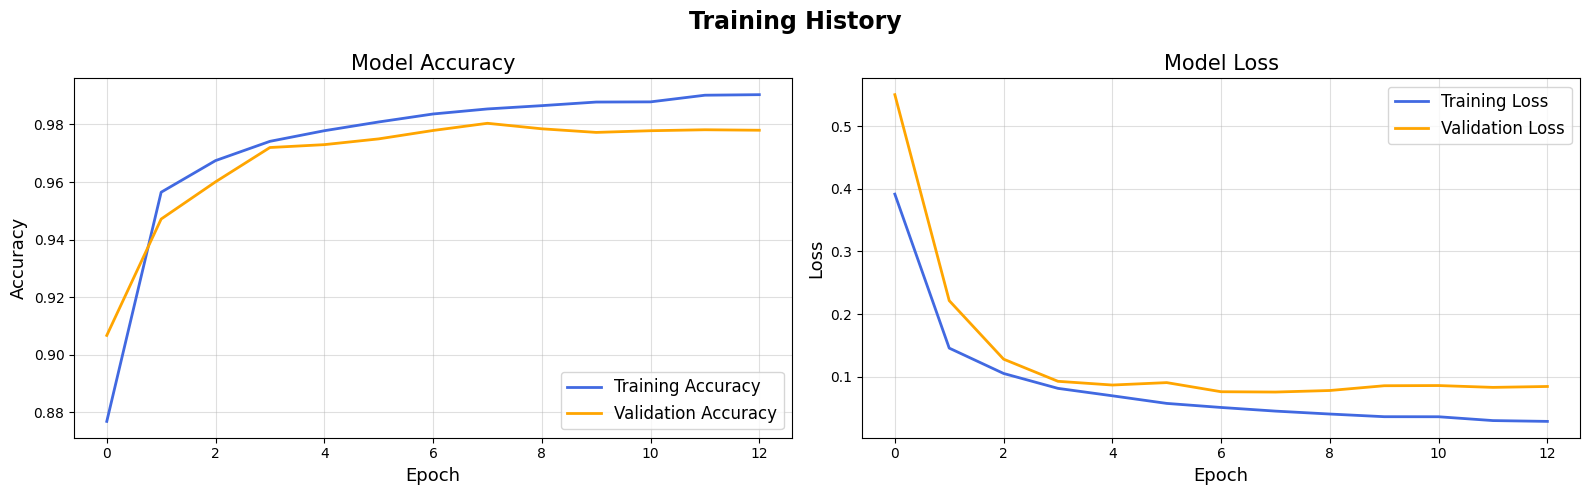

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))  # 1 row, 2 columns; each subplot 8×5 inches

# ── Accuracy plot ─────────────────────────────────────────────────────────────
ax1.plot(history.history['accuracy'],     label='Training Accuracy',   color='royalblue', linewidth=2)  # Accuracy on training data per epoch
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange',    linewidth=2)  # Accuracy on validation data per epoch
ax1.set_xlabel('Epoch', fontsize=13)        # x-axis label
ax1.set_ylabel('Accuracy', fontsize=13)     # y-axis label
ax1.set_title('Model Accuracy', fontsize=15)  # Plot title
ax1.legend(fontsize=12)   # Show legend to distinguish training vs validation
ax1.grid(True, alpha=0.4) # Light grid lines to aid reading

# ── Loss plot ─────────────────────────────────────────────────────────────────
ax2.plot(history.history['loss'],     label='Training Loss',   color='royalblue', linewidth=2)  # Loss on training data per epoch
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange',    linewidth=2)  # Loss on validation data per epoch
ax2.set_xlabel('Epoch', fontsize=13)     # x-axis label
ax2.set_ylabel('Loss', fontsize=13)      # y-axis label
ax2.set_title('Model Loss', fontsize=15) # Plot title
ax2.legend(fontsize=12)   # Show the legend
ax2.grid(True, alpha=0.4) # Light grid lines

plt.suptitle('Training History', fontsize=17, fontweight='bold')  # Overall title for both subplots
plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()          # Display the figure

---
## 🧪 Section 9 — Evaluate on the Test Set

Now we measure performance on **data the model has never seen** — the real test.

In [16]:
# Evaluate the model on the held-out test set
# Returns the test loss and test accuracy as two separate values
# y_test contains plain integer labels — compatible with sparse_categorical_crossentropy
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)  # verbose=0 silences per-batch output

print(f'Test Accuracy : {test_acc * 100:.2f}%')  # Multiply by 100 to display as a percentage
print(f'Test Loss     : {test_loss:.4f}')         # Show loss to 4 decimal places

Test Accuracy : 97.99%
Test Loss     : 0.0672


---
## 🔮 Section 10 — Visualize Predictions

Let's see the model in action — display test images with both the **true label** and the **model's prediction**.  
Green title = correct prediction ✓ | Red title = wrong prediction ✗

In [17]:
# Generate predictions for all 10,000 test images
# model.predict() returns a (10000, 10) array of probabilities — one probability per digit class
y_pred_probs = model.predict(x_test, verbose=0)  # Shape: (10000, 10)

# Convert probabilities to final predicted class labels
# np.argmax returns the index of the highest probability along axis=1 (across the 10 class columns)
# e.g., [0.01, 0.02, 0.01, 0.90, ...] → 3  (index of the max value)
y_pred = np.argmax(y_pred_probs, axis=1)  # Shape: (10000,) — one integer digit per image

print(f'Predictions generated for {len(y_pred)} test images.')
print(f'Sample — True: {y_test[:5]}, Predicted: {y_pred[:5]}')

Predictions generated for 10000 test images.
Sample — True: [7 2 1 0 4], Predicted: [7 2 1 0 4]


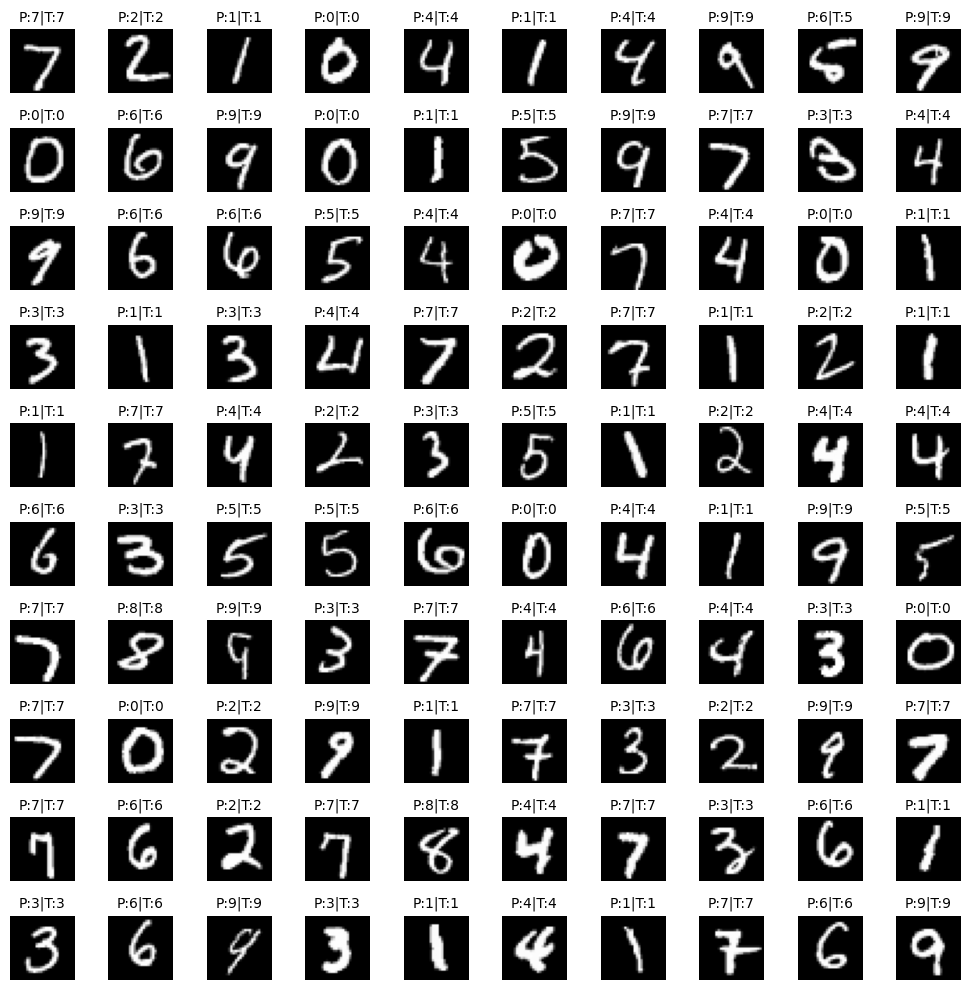

In [20]:
# Display a 10×10 grid of test images annotated with predicted and true labels
fig = plt.figure(figsize=(10, 10))  # Wide figure to fit 100 images

for q in range(100):  # Loop over the first 100 test images
    ax = fig.add_subplot(10, 10, q + 1)  # Add a subplot in a 10-row × 10-column grid

    plt.imshow(x_test[q].reshape(28, 28), cmap='gray')  # Reshape to 2D to remove the channel dimension for display

    pred = y_pred[q]   # The model's predicted digit for this image
    true = y_test[q]   # The actual correct digit

    color = 'green' if pred == true else 'red'  # Green if correct, red if wrong
    ax.set_title(f'P:{pred}|T:{true}', fontsize=10, color='k')  # P=Predicted, T=True
    plt.axis('off')  # Hide axis ticks and numbers
plt.tight_layout()  # Adjust layout


---
## ❌ Section 11 — Inspect Misclassified Images

Understanding **where the model fails** is just as important as knowing where it succeeds.  
Looking at mistakes helps us improve the model or understand its limitations.

Total wrong predictions : 201 out of 10000
Error rate              : 2.01%


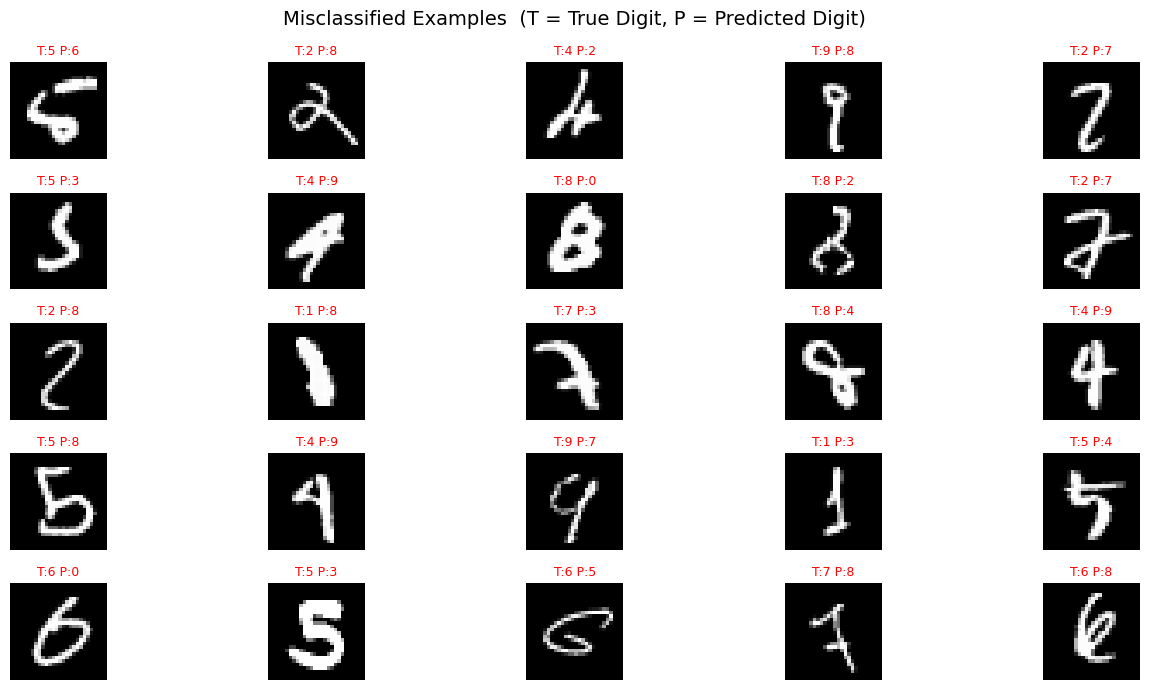

In [21]:
# Find the indices of all images where the model predicted the wrong digit
# np.where returns a tuple; [0] extracts the array of matching indices
wrong_indices = np.where(y_pred != y_test)[0]  # All indices where prediction != true label

print(f'Total wrong predictions : {len(wrong_indices)} out of {len(y_test)}')  # Error count
print(f'Error rate              : {len(wrong_indices)/len(y_test)*100:.2f}%')   # As a percentage

# Visualize the first 25 misclassified images in a 5×5 grid
fig = plt.figure(figsize=(14, 7))  # Create figure
for i, idx in enumerate(wrong_indices[:25]):  # Take the first 25 wrong examples
    ax = fig.add_subplot(5, 5, i + 1)  # 5-row × 5-column subplot grid
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')  # Display the misclassified image
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}', fontsize=9, color='red')  # True vs Predicted
    plt.axis('off')  # No axis labels

plt.suptitle('Misclassified Examples  (T = True Digit, P = Predicted Digit)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 💾 Section 13 — Save the Trained Model

After training, we save the model so it can be loaded later without retraining from scratch.

In [ ]:
# Save the entire model: architecture + learned weights + compilation settings
# The '.keras' format is the modern recommended format in Keras 3
model.save('mnist_mlp_model.keras')  # Saves to the current working directory

print('Model saved as: mnist_mlp_model.keras')

# ── To reload the model later (no retraining needed): ─────────────────────────
# loaded_model = keras.models.load_model('mnist_mlp_model.keras')
# loaded_model.predict(...)  ← ready to make predictions immediately

---
## 📋 Summary

Here is everything we covered in this notebook:

| Step | What we did |
|------|-------------|
| 1 | Imported all necessary libraries |
| 2 | Loaded the MNIST dataset (70,000 digit images) |
| 3 | Explored data: shapes, pixel ranges, class distribution |
| 4 | Normalised pixels to [0,1]; kept labels as plain integers (no one-hot encoding) |
| 5 | Built a 3-hidden-layer MLP with BatchNorm and Dropout |
| 6 | Compiled with Adam optimizer and **sparse** categorical crossentropy loss |
| 7 | Trained with EarlyStopping callback |
| 8 | Visualised training accuracy and loss curves |
| 9 | Evaluated on the held-out test set |
| 10 | Visualised predictions and inspected misclassified examples |
| 11 | Saved the model for future use |

---

## 🚀 What to explore next

- **CNN (Convolutional Neural Network)** — more powerful for images; uses spatial filters to detect edges and shapes
